In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install skorch #scikit-learn lib that dialogues with pytorch

In [28]:
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from skorch import NeuralNetClassifier #involve the NN and create method fit to search the hyperparameters

# Loading the database

In [6]:
path = '/content/drive/MyDrive/datasets/MLP-UniDisc/stroke.csv'
df = pd.read_csv(path)

# Pre-processing the data

In [7]:
df[df.isnull().any(axis=1)] #show the lines that is lefting some data
df = df.dropna() #removing the rows that are not fully

In [8]:
x = df.iloc[:,1:-1] #remove the id column and remove the stroke column
y = df.iloc[:,-1] #separating the result column to a diff variable
x

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked
...,...,...,...,...,...,...,...,...,...,...
5104,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked


In [9]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
cols = [ 'ever_married', 'Residence_type']
le = LabelEncoder()
x[cols] = x[cols].apply(le.fit_transform)

#for this case that have more than 3 possibilities we use OneHotEncoder, it operation transform each type into a binary number, e.g. using the gender case -  We have 'Male', 'Female' and 'Other',
# Male will be 001 Female 010 and Other 100, using this we avoid to the NN to learn wrongs relations, like Female > Other or something like this
ct = ColumnTransformer(transformers=[('encoders', OneHotEncoder(), ['gender', 'work_type', 'smoking_status'])], remainder = 'passthrough')
x = ct.fit_transform(x)
x[0]

array([  0.  ,   1.  ,   0.  ,   0.  ,   0.  ,   1.  ,   0.  ,   0.  ,
         0.  ,   1.  ,   0.  ,   0.  ,  67.  ,   0.  ,   1.  ,   1.  ,
         1.  , 228.69,  36.6 ])

In [10]:
colunas = ['ohe1', 'ohe2', 'ohe3', 'ohe4', 'ohe5', 'ohe6', 'ohe7', 'ohe8', 'ohe9', 'ohe10', 'ohe11',
           'ohe12', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type',
           'avg_glucose_level', 'bmi']
pd.DataFrame(x, columns=colunas)



,ohe1,ohe2,ohe3,ohe4,ohe5,ohe6,ohe7,ohe8,ohe9,ohe10,ohe11,ohe12,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,67.0,0.0,1.0,1.0,1.0,228.69,36.6
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,80.0,0.0,1.0,1.0,0.0,105.92,32.5
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,49.0,0.0,0.0,1.0,1.0,171.23,34.4
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,79.0,1.0,0.0,1.0,0.0,174.12,24.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,81.0,0.0,0.0,1.0,1.0,186.21,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4904,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,13.0,0.0,0.0,0.0,0.0,103.08,18.6
4905,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,81.0,0.0,0.0,1.0,1.0,125.20,40.0
4906,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,35.0,0.0,0.0,1.0,0.0,82.99,30.6
4907,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,51.0,0.0,0.0,1.0,0.0,166.29,25.6


In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.15) #separating the cases of test and training
print(type(x_train[0]))
print(type(y_train[0]))

<class 'numpy.ndarray'>
<class 'numpy.int64'>


In [12]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train) #normaliza os dados -> média e desvio padrão
x_test = sc.transform(x_test) #normaliza os dados de test com os valores normalizados de x_train


# Building the NN

In [11]:
class NN (nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(19,6),
        nn.ReLU(),
        nn.Linear(6,6),
        nn.ReLU(),
        nn.Linear(6,1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.layers(x)

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
model = NN().to(device)

# Optimizing the hyperparameters

In [ ]:
net = NeuralNetClassifier(
    module = NN,
    criterion = nn.BCEWithLogitsLoss,
    optimizer = torch.optim.Adam,
    device = device
)

batch_arr = [16,32,64]

epoch_arr = [10,20,30,40,50,60]

x_train_float = x_train.astype(np.float32)
y_train_float = y_train.values.astype(np.float32).reshape(-1,1)


param_grid = {
    'optimizer': [torch.optim.SGD, torch.optim.Adam],
    'batch_size': batch_arr,
    'max_epochs': epoch_arr

}

grid = GridSearchCV(estimator=net, param_grid=param_grid,n_jobs=None, cv=2)
grid_result = grid.fit(x_train_float, y_train_float)

In [ ]:
print(f'Best score {grid_result.best_score_} and best params {grid_result.best_params_}')
means = grid_result.cv_results_['mean_test_score']
std = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, std, params):
  print("%f (%f) with %r" % (mean,stdev, param))

In [ ]:
loss_func = nn.BCELoss()
optimizer = torch.optim.Adam(params= model.parameters(), lr = 0.001)

# Transforming the data in Tensors

In [ ]:
# transforma os vetores de x_train e y_train em tensores
x_train_tensor = torch.tensor(x_train, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32, device=device)
# junta os tensores de x e y, formando uma tupla
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
# separa em batchs de tamanho 32 os dados de train_dataset
train_dataloader = DataLoader(train_dataset,batch_size=32,shuffle=True)

x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device = device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32, device = device)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)


# Building the Train and Test Function

In [ ]:
def train(model, dataloader, lossfunc, optimizer):
  Y_train_pred = []
  model.train() #treina o modelo -> treina é um método do próprio Pytorch

  cumloss = 0.0
  for data, expect in dataloader:
    data = data.to(device) #é necessário ?
    expect = expect.unsqueeze(1).to(device) #é necessário ?

    pred = model(data) #modelo prediz a resposta a partir dos dados inseridos
    Y_train_pred.append(pred)
    loss = loss_func(pred, expect) # passa as informações que dos dados preditos e compara com os dados esperados
    optimizer.zero_grad() #zera os gradientes acumulados
    loss.backward() #calcula os gradientes em direção de reduzir ele
    optimizer.step() #anda em sentido do menor gradiente (anda o passo calculado)

    cumloss += loss.item() #o que o item() faz ?

  return cumloss/len(dataloader)

def test(model, dataloader, loss_func):
  Y_test_pred = []
  Y_test_true = []
  model.eval() # semelhante ao .train(), mas é melhor para teste
  cumloss = 0.0
  with torch.no_grad(): #turn off gradients computation
    for X, y in dataloader:
      X = X.to(device)
      y = y.unsqueeze(1).to(device)

      pred = model(X)
      loss = loss_func(pred, y)

      cumloss += loss.item()

      pred_binario = torch.round(pred).float()
      Y_test_pred.extend(pred_binario.cpu().numpy().flatten())
      Y_test_true.extend(y.cpu().numpy().flatten())
  return cumloss/len(dataloader), Y_test_pred, Y_test_true

# Training and Testing

In [ ]:
epochs = 201
for t in range(epochs):
  train_loss = train(model, train_dataloader, loss_func, optimizer)
  if t % 10 == 0:
    print(f'Epoch {t} - Error: {train_loss}')

test_loss, y_pred, y_true = test(model, test_dataloader,loss_func)
print(f'Test Loss: {test_loss}')


In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.show()

Analisando a confusion matrix, o modelo parece ter apenas chutado na maior parte do tempo que é melhor dizer que um paciente não terá AVC, como a base de dados, possui mais dados de pacientes sem AVC, essa foi a saída tomada

In [ ]:
accuracy_score(y_true, y_test)

# Exemplo 2

In [83]:
path_train = '/content/drive/MyDrive/datasets/MLP-UniDisc/fashion-mnist_train.csv'
path_test = '/content/drive/MyDrive/datasets/MLP-UniDisc/fashion-mnist_test.csv'

dataset_train = pd.read_csv(path_train)
dataset_test = pd.read_csv(path_test)

#os datasets são dados de metrizes de imagens 28x28 - label é a classificação do objeto

x_train = dataset_train.iloc[:,1:]
y_train = dataset_train.iloc[:,0]

x_test = dataset_test.iloc[:,1:]
y_test = dataset_test.iloc[:,0]

In [84]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train) #normaliza os dados -> média e desvio padrão
x_test = sc.transform(x_test) #normaliza os dados de test com os valores normalizados de x_train

In [85]:
class NN2(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.layers = nn.Sequential(
        nn.Linear(784,128),
        nn.ReLU(),
        nn.Linear(128,10),
        nn.ReLU(),
        nn.Linear(10,10)
    )

  def forward(self,image):
    v = self.flatten(image)
    return self.layers(v)

In [17]:
net = NeuralNetClassifier(
    module = NN2,
    criterion = nn.CrossEntropyLoss,
    optimizer = torch.optim.Adam,
    device = device
)

batch_arr = [16,32]

epoch_arr = [10,20]

x_train_float = x_train.astype(np.float32)
y_train_float = y_train.values.astype(np.int64) #não aceita valores floats, pois são categorias já definidas que são números inteiros


param_grid = {
    'optimizer': [torch.optim.SGD, torch.optim.Adam],
    'batch_size': batch_arr,
    'max_epochs': epoch_arr

}

grid = GridSearchCV(estimator=net, param_grid=param_grid,n_jobs=None, cv=2)
grid_result = grid.fit(x_train_float, y_train_float)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.9195       0.8112        0.5330  3.1011
      2        0.4838       0.8435        0.4458  2.7815
      3        0.4174       0.8538        0.4119  3.3079
      4        0.3791       0.8620        0.3930  2.8787
      5        0.3509       0.8635        0.3815  2.8159
      6        0.3277       0.8638        0.3773  2.8458
      7        0.3074       0.8662        0.3740  2.8696
      8        0.2896       0.8663        0.3715  3.3165
      9        0.2730       0.8673        0.3715  2.7608
     10        0.2576       0.8685        0.3725  2.7672
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.8844       0.7343        0.7657  2.7194
      2        0.4695       0.7765        0.6307  3.2012
      3        0.4058       0.7942        0.5764  3.0819
      4        0.3688       0.8

In [42]:
print(f'Best score {grid_result.best_score_} and best params {grid_result.best_params_}')
means = grid_result.cv_results_['mean_test_score']
std = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, std, params):
  print("%f (%f) with %r" % (mean,stdev, param))

Best score 0.85895 and best params {'batch_size': 32, 'max_epochs': 20, 'optimizer': <class 'torch.optim.sgd.SGD'>}
0.848500 (0.022267) with {'batch_size': 16, 'max_epochs': 10, 'optimizer': <class 'torch.optim.sgd.SGD'>}
0.437983 (0.016850) with {'batch_size': 16, 'max_epochs': 10, 'optimizer': <class 'torch.optim.adam.Adam'>}
0.858133 (0.013900) with {'batch_size': 16, 'max_epochs': 20, 'optimizer': <class 'torch.optim.sgd.SGD'>}
0.678633 (0.086000) with {'batch_size': 16, 'max_epochs': 20, 'optimizer': <class 'torch.optim.adam.Adam'>}
0.850500 (0.019067) with {'batch_size': 32, 'max_epochs': 10, 'optimizer': <class 'torch.optim.sgd.SGD'>}
0.760400 (0.036967) with {'batch_size': 32, 'max_epochs': 10, 'optimizer': <class 'torch.optim.adam.Adam'>}
0.858950 (0.016317) with {'batch_size': 32, 'max_epochs': 20, 'optimizer': <class 'torch.optim.sgd.SGD'>}
0.679717 (0.058217) with {'batch_size': 32, 'max_epochs': 20, 'optimizer': <class 'torch.optim.adam.Adam'>}


In [43]:
model = NN2().to(device)

In [86]:
lossfunc = loss_func = nn.CrossEntropyLoss()
optim = torch.optim.SGD(model.parameters(), lr = 0.002)

In [91]:
def train(model, dataloader, loss_func, optimizer):
  model.train()
  cumloss = 0.0

  for imgs, labels in dataloader:
    imgs, labels = imgs.to(device), labels.to(device)
    pred = model(imgs)

    loss = loss_func(pred, labels)
    #zera os gradientes acumulados
    optimizer.zero_grad()
    #computa os gradientes
    loss.backward()
    # anda no sentido de diminuir o gradiente, ou seja, reduz o erro local
    optimizer.step()

    cumloss += loss.item()

  return cumloss/len(dataloader)

def validate(model, dataloader, lossfunc):
  pred_list = []
  real_list = []
  model.eval()
  cumloss = 0.0

  with torch.no_grad():
    for imgs, labels in dataloader:
      imgs, labels = imgs.to(device), labels.to(device)
      pred = model(imgs)
      max = torch.max(pred,1)
      cl_pred = max[1]
      pred_list.extend(cl_pred.cpu().numpy())
      real_list.extend(labels.cpu().numpy())
      loss = lossfunc(pred, labels)
      cumloss += loss.item()

  return cumloss/len(dataloader), pred_list, real_list

In [92]:
x_train_tensor = torch.tensor(x_train, dtype = torch.float32, device=device)
y_train_tensor = torch.tensor(y_train, dtype=torch.int64, device=device)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

train_dataloader = DataLoader(train_dataset, batch_size = 32, shuffle= False)

x_test_tensor = torch.tensor(x_test, dtype= torch.float32, device=device)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.int64, device=device)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=32)

In [93]:
epochs = 21
for e in range(epochs):
  train_loss = train(dataloader=train_dataloader,model=model,loss_func=lossfunc,optimizer=optim)
  if(e % 10 == 0):
    print(f'Loss Value: {train_loss}')
test_loss, pred_list, real_list = validate(model=model,dataloader=test_dataloader,lossfunc=lossfunc)
print(f'Test Loss: {test_loss}')

Loss Value: 0.045468233281684416
Loss Value: 0.03846876959123959
Loss Value: 0.03255875636227429
Test Loss: 0.532412633927652


In [94]:
print(pred_list)
print(real_list)

[np.int64(0), np.int64(1), np.int64(2), np.int64(6), np.int64(4), np.int64(6), np.int64(8), np.int64(4), np.int64(5), np.int64(0), np.int64(3), np.int64(4), np.int64(4), np.int64(6), np.int64(8), np.int64(5), np.int64(4), np.int64(3), np.int64(6), np.int64(4), np.int64(4), np.int64(4), np.int64(2), np.int64(1), np.int64(5), np.int64(7), np.int64(8), np.int64(4), np.int64(4), np.int64(1), np.int64(5), np.int64(7), np.int64(7), np.int64(8), np.int64(1), np.int64(0), np.int64(9), np.int64(6), np.int64(0), np.int64(8), np.int64(2), np.int64(0), np.int64(4), np.int64(6), np.int64(2), np.int64(0), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(4), np.int64(9), np.int64(3), np.int64(0), np.int64(9), np.int64(9), np.int64(4), np.int64(0), np.int64(0), np.int64(4), np.int64(5), np.int64(4), np.int64(6), np.int64(1), np.int64(1), np.int64(0), np.int64(9), np.int64(5), np.int64(2), np.int64(7), np.int64(3), np.int64(4), np.int64(3), np.int64(5), np.int64(7), np.int64(1)

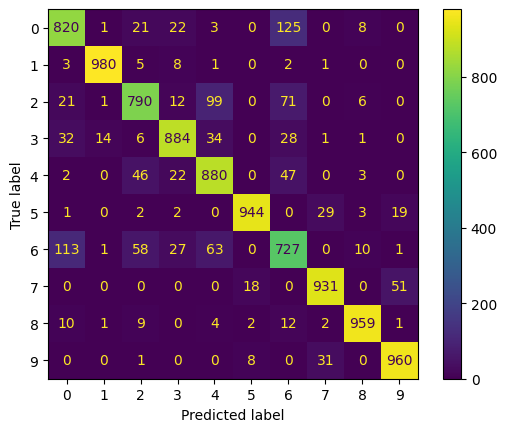

In [95]:
cm = confusion_matrix(real_list, pred_list)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.show()

In [96]:
accuracy_score(y_pred=pred_list,y_true=real_list)

0.8875